In [2]:
from matplotlib import pyplot as plt
from scipy.spatial.distance import cdist
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score

import torch
import numpy as np
from copy import deepcopy


from torch import nn
from umap import UMAP

from run_sim import Config, run_sim, run_sim_wrapper, create_data
from utils import *
from tqdm import tqdm
from tqdm import tqdm
from utils import *
import matplotlib as mpl
import scipy
from scipy.special import softmax
from functools import reduce
from utils_plot import plot_pca



In [3]:
def calc_h_var(G, D, N, L, sig_X):
    return G**(2*L)*(2*D*sig_X)/(D+N)

In [4]:
C = Config()

C.G = 0.5
C.sig_h_2 = None
# C.gpu_id=1
# C.seed = 1
C.linear_net = True
# C.split_actions = True
# C.allow_backwards = True
C.learning_rate = 0.0001
C.L=1
C.print_progress = True
C.algo_name = 'Adam'
C.loss_fn = nn.MSELoss()
C.length_corridors = [100]*1
# C.input_size = 10
C.max_move = 5
C.hidden_size = 250 # (C.length_corridors[0]+2*C.max_move+1 + 1)*len(C.length_corridors)
C.num_epochs = 1
C.cyclic_corridors = False
C.one_hot_inputs = False
C.one_hot_actions = False
C.scalar_actions = False

In [5]:
data_dict_l = []
for max_move in [1, C.length_corridors[0]//4 , C.length_corridors[0]//2]:
    C.max_move = max_move
    data_dict = run_sim_wrapper(C)
    data_dict_l.append(data_dict)

Number of samples: 298
Input dimension: 103
Output dimension: 100
Number of actions: 3

Sig_2 of last hidden: 0.14277835190296173


100%|██████████| 1/1 [00:00<00:00,  8.01it/s]


Number of samples: 4450
Input dimension: 151
Output dimension: 100
Number of actions: 51

Sig_2 of last hidden: 0.18381495773792267


100%|██████████| 1/1 [00:00<00:00, 12.04it/s]


Number of samples: 7550
Input dimension: 201
Output dimension: 100
Number of actions: 101

Sig_2 of last hidden: 0.22205744683742523


100%|██████████| 1/1 [00:00<00:00,  4.69it/s]


In [6]:
# for data_dict in data_dict_l:
#     plot_pca(data_dict)

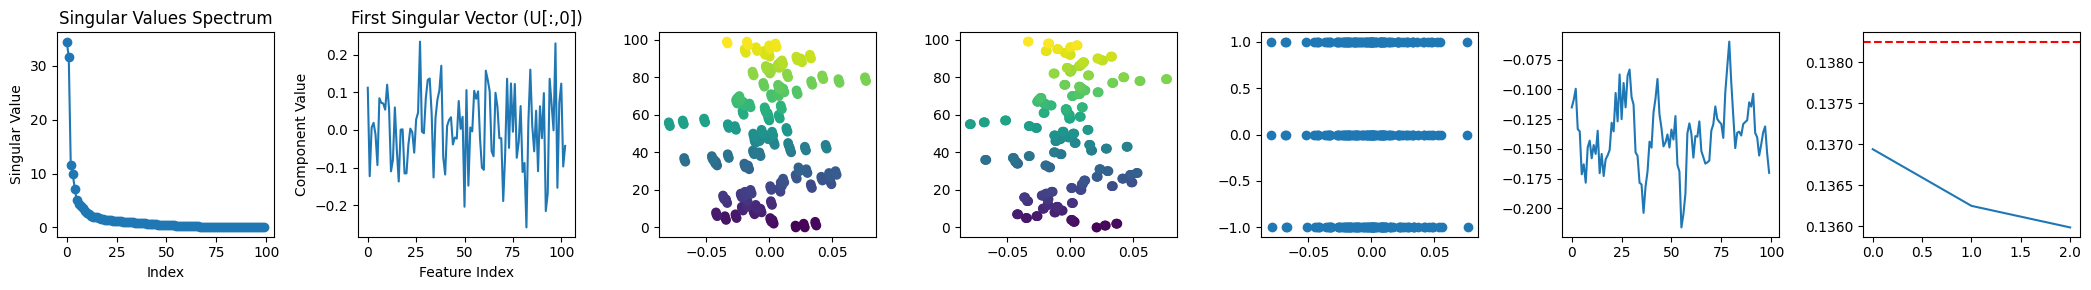

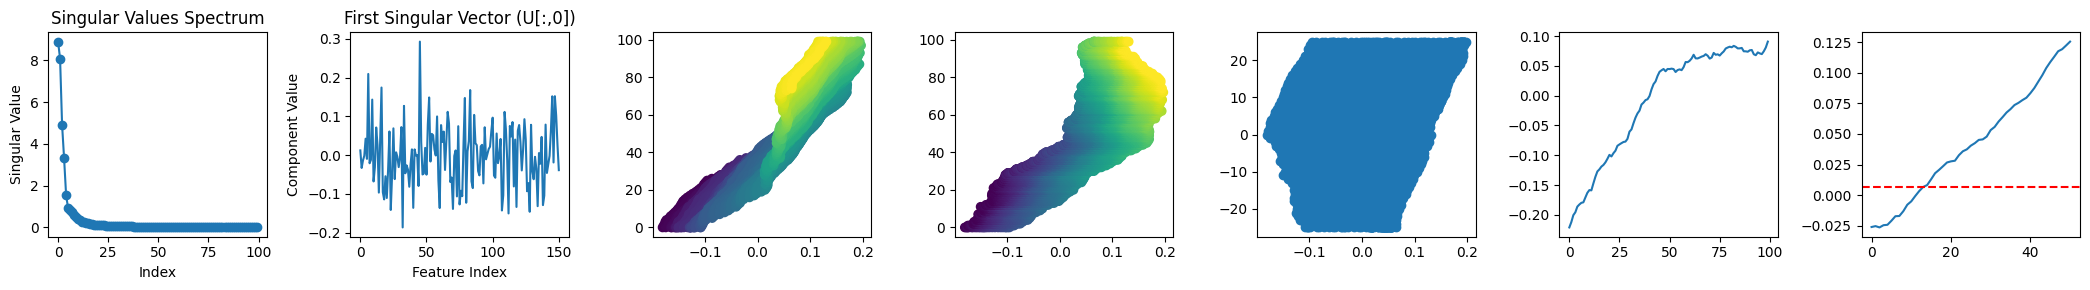

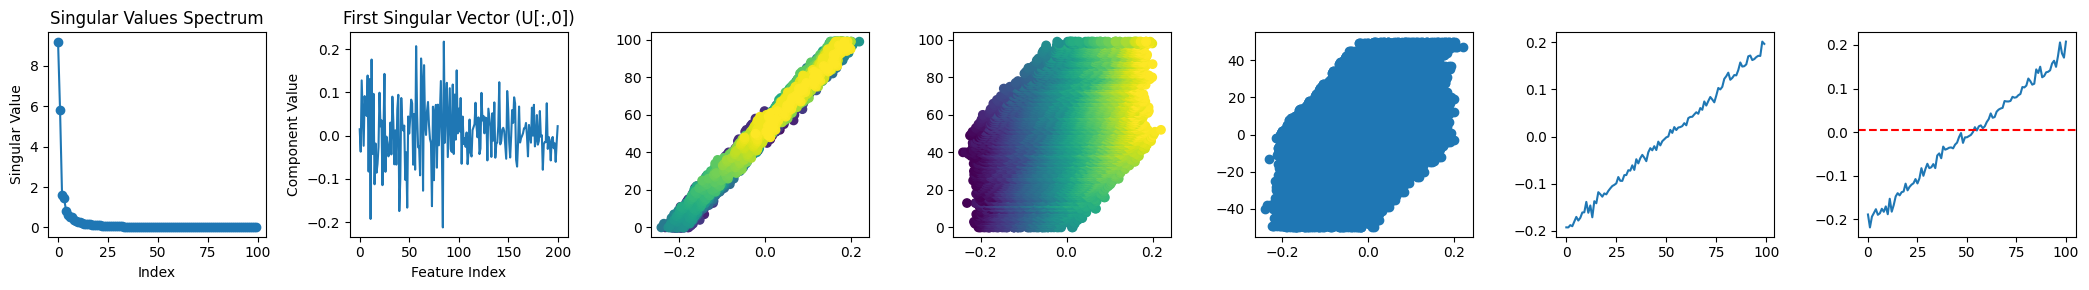

In [7]:
for data_dict in data_dict_l:
    X = data_dict['X']
    y = data_dict['y']
    loc_y = data_dict['loc_y']
    loc_x = data_dict['loc_X']
    action_taken = data_dict['action_taken']
    env_size = data_dict['C'].length_corridors[0]
    N = X.shape[0]

    XT_X = X.T @ X /N
    XT_y = X.T @ y /N
    S = torch.linalg.pinv(XT_X) @ XT_y  

    cond = abs(action_taken) <= 1

    # Singular value decomposition
    U, s, Vt = torch.linalg.svd(S)
    s = s.cpu().numpy()
    U = U.cpu().numpy()
    
    # Plot singular values spectrum
    plt.figure(figsize=(21, 3))
    n = 7
    plt.subplot(1, n, 1)
    plt.plot(s, 'o-')
    plt.title('Singular Values Spectrum')
    plt.xlabel('Index')
    plt.ylabel('Singular Value')

    # Plot first singular vector
    plt.subplot(1, n, 2)
    plt.plot(U[:, 0])
    # plt.plot(U[:, 1], '-')
    plt.title('First Singular Vector (U[:,0])')
    plt.xlabel('Feature Index')
    plt.ylabel('Component Value')

    plt.subplot(1, n, 3)
    cond = abs(action_taken) <= 1000
    X = X.cpu().numpy()[cond]
    # plt.scatter(X@U[:, 0], X@U[:, 1], c=loc_y[cond])
    # plt.axis('equal')
    plt.scatter(X@U[:, 0], loc_y[cond], c=loc_x[cond])
    # plt.scatter(X@U[:, 1], loc_y[cond])
    # plt.scatter(X@U[:, 2], loc_y[cond])

    plt.subplot(1, n, 4)
    # plt.scatter(X@U[:, 0], X@U[:, 1], c=loc_y[cond])
    # plt.axis('equal')
    plt.scatter(X@U[:, 0], loc_x[cond], c=loc_y[cond])
    # plt.scatter(X@U[:, 1], loc_x[cond])
    # plt.scatter(X@U[:, 2], loc_x[cond])

    plt.subplot(1, n, 5)
    # plt.scatter(X@U[:, 0], X@U[:, 1], c=loc_y[cond])
    # plt.axis('equal')
    plt.scatter(X@U[:, 0], action_taken[cond])
    # plt.scatter(X@U[:, 1], action_taken[cond])
    # plt.scatter(X@U[:, 2], action_taken[cond])

    vecs = []
    vecs_a = []
    for i in np.unique(loc_x):
        vecs.append(X[loc_x==i][0,:env_size])
    for a in np.unique(action_taken):
        vecs_a.append(X[action_taken==a][0,env_size:])
    vecs = np.array(vecs)
    vecs_a = np.array(vecs_a)
    plt.subplot(1, n, 6)
    plt.plot(vecs@U[:env_size, 0])
    plt.subplot(1, n, 7)
    plt.plot(vecs_a@U[env_size:, 0])
    plt.axhline(-(vecs@U[:env_size, 0]).mean(), c='red', ls='--')
    plt.tight_layout()
    plt.show()


/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


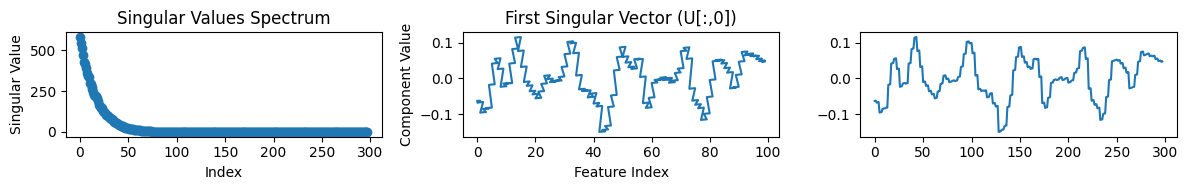

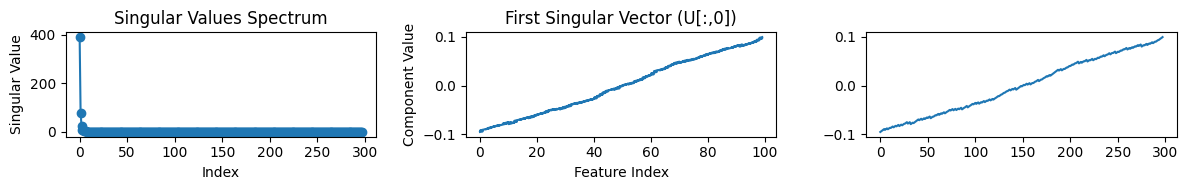

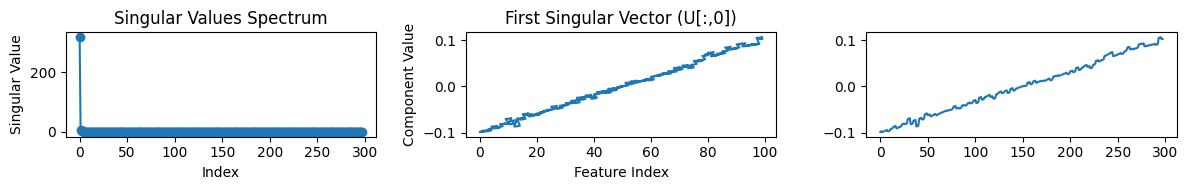

In [8]:
for data_dict in data_dict_l:
    X = data_dict['X']
    y = data_dict['y']
    loc_y = data_dict['loc_y']
    action_taken = data_dict['action_taken']
    N = X.shape[0]

    XT_X = X.T @ X /N
    XT_y = X.T @ y /N
    S = torch.linalg.pinv(XT_X) @ XT_y  

    cond = abs(action_taken) <= 1

    # Singular value decomposition
    # U, s, Vt = torch.linalg.svd(X@S)
    # s = s.cpu().numpy()
    # U = U.cpu().numpy()
    y_hat = X[cond]@S
    y_hat_white = y_hat - y_hat.mean(0, keepdims=True)
    eigs, eigs_v = torch.linalg.eig(y_hat_white@y_hat_white.T)
    eigs = eigs.cpu().numpy()
    eigs_v = eigs_v.cpu().numpy()
    # Plot singular values spectrum
    plt.figure(figsize=(12, 2))
    plt.subplot(1, 3, 1)
    plt.plot(eigs, 'o-')
    plt.title('Singular Values Spectrum')
    plt.xlabel('Index')
    plt.ylabel('Singular Value')

    # Plot first singular vector
    plt.subplot(1, 3, 2)
    plt.plot(loc_y[cond], eigs_v[:, 0])
    # plt.plot(U[:, 1], '-')
    plt.title('First Singular Vector (U[:,0])')
    plt.xlabel('Feature Index')
    plt.ylabel('Component Value')
    
    plt.subplot(1, 3, 3)
    plt.plot(eigs_v[:, 0])

    plt.tight_layout()
    plt.show()


In [9]:

X = data_dict['X']
y = data_dict['y']
loc_y = data_dict['loc_y']
action_taken = data_dict['action_taken']
N = X.shape[0]

XT_X = X.T @ X /N
XT_y = X.T @ y /N
W = torch.linalg.pinv(XT_X) @ XT_y  

XW = (X@W).cpu().numpy()
y = y.cpu().numpy()


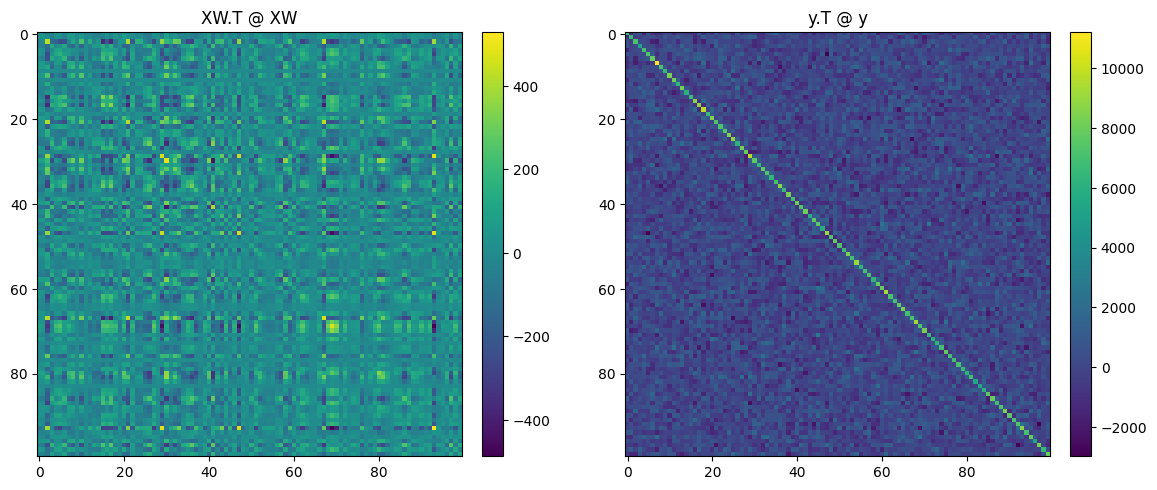

In [10]:
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

im0 = axs[0].imshow(XW.T @ XW)
axs[0].set_title("XW.T @ XW")
plt.colorbar(im0, ax=axs[0], fraction=0.05, pad=0.04)

im1 = axs[1].imshow(y.T @ y)
axs[1].set_title("y.T @ y")
plt.colorbar(im1, ax=axs[1], fraction=0.05, pad=0.04)

plt.tight_layout()
plt.show()


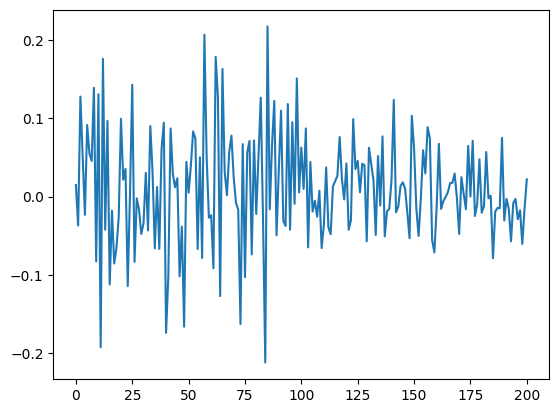

In [11]:
plt.plot(U[:,0])

<>:27: SyntaxWarning: invalid escape sequence '\l'
<>:27: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_1257928/509774222.py:27: SyntaxWarning: invalid escape sequence '\l'
  axs[1].set_title("$\left(X^T X\\right)^{-1}$")


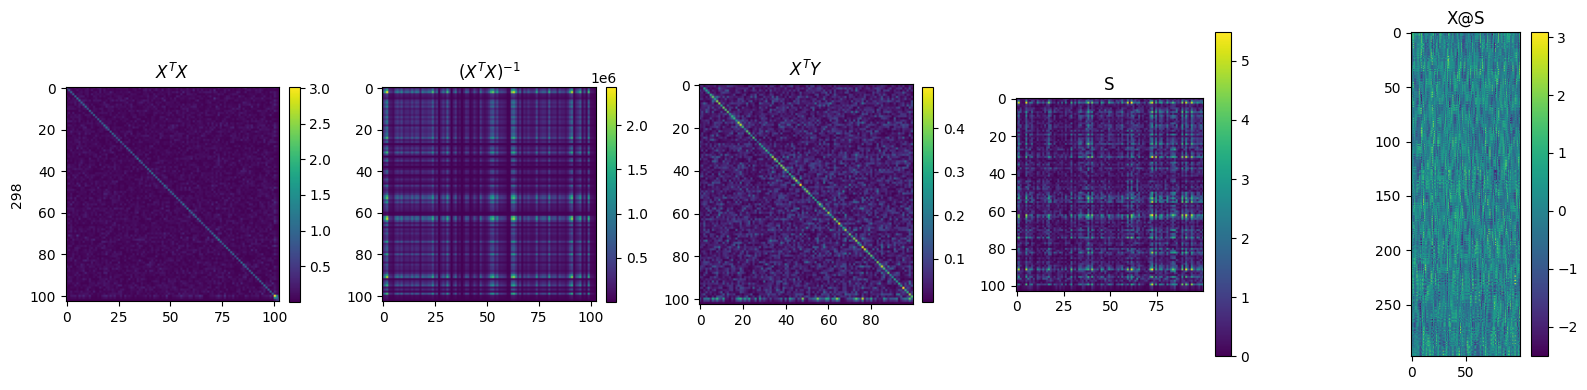

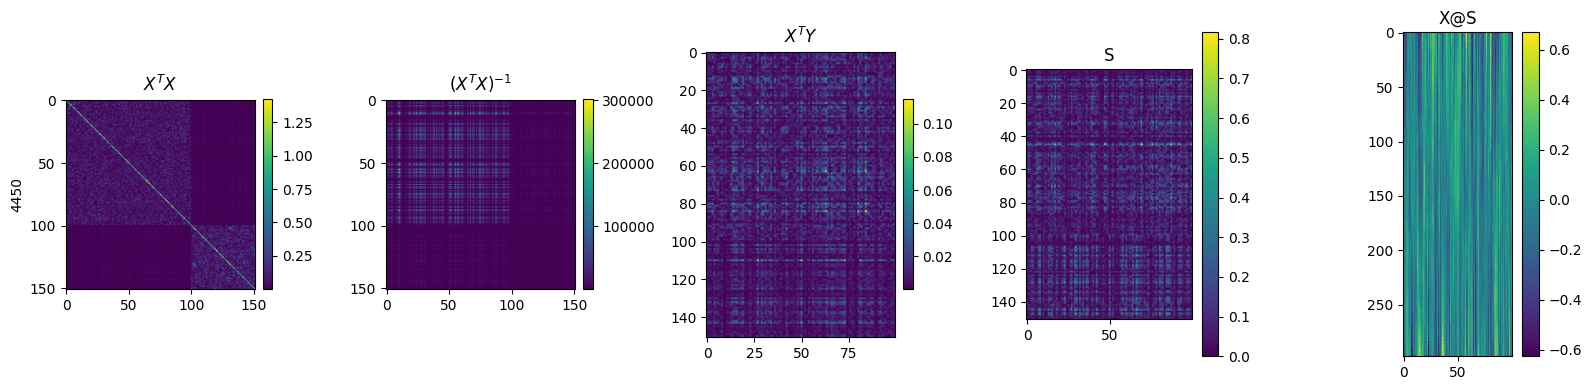

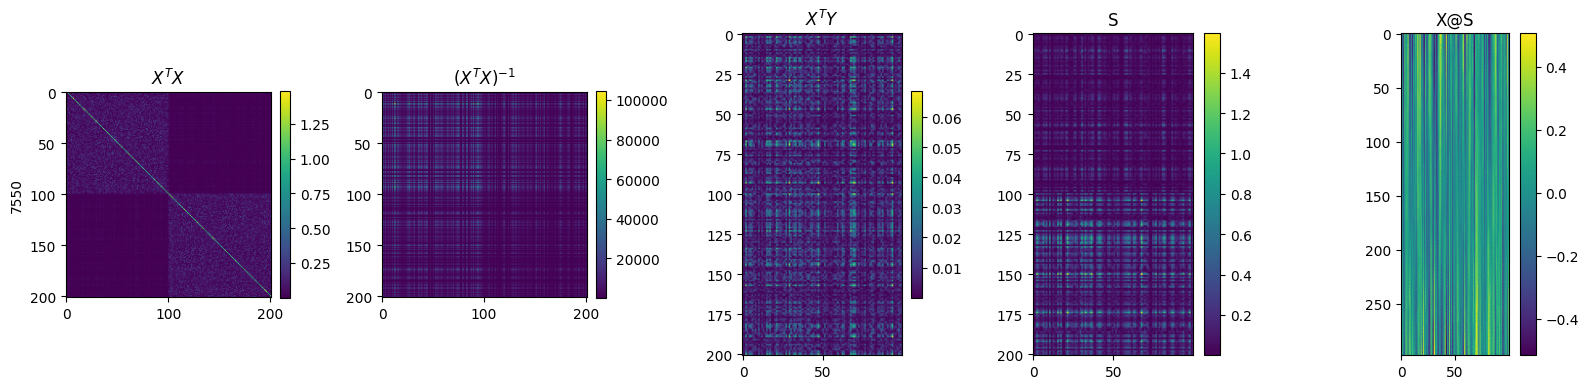

In [12]:
for data_dict in data_dict_l:
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()
    action_taken = data_dict['action_taken']
    loc_y = data_dict['loc_y']
    N = X.shape[0]

    XT_X = X.T @ X /N
    XT_y = X.T @ y /N
    S = np.linalg.pinv(XT_X) @ XT_y  
    # Visualize the key OLS matrices as images

    fig, axs = plt.subplots(1, 5, figsize=(16, 4))

    # 1. X^T X
    im0 = axs[0].imshow(abs(XT_X))
    axs[0].set_title("$X^T X$")
    plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
    axs[0].set_ylabel(N)

    # 2. inv(X^T X) X^T y
    # This is S as computed previously, but let's show the intermediate inv(X^T X) @ XT_y too
    XTX_inv = np.linalg.pinv(XT_X)
    XTX_inv_XTy = XTX_inv @ XT_y

    im1 = axs[1].imshow(abs(XTX_inv))
    axs[1].set_title("$\left(X^T X\\right)^{-1}$")
    plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)


    im1 = axs[2].imshow(abs(XT_y))
    axs[2].set_title("$X^TY$")
    plt.colorbar(im1, ax=axs[2], fraction=0.046, pad=0.04)

    # 3. S
    im2 = axs[3].imshow(abs(S))
    axs[3].set_title("S")
    plt.colorbar(im2, ax=axs[3])

    cond = abs(action_taken) <= 1
    im = axs[4].imshow(X[cond][loc_y[cond].argsort()]@S)
    axs[4].set_title("X@S")
    plt.colorbar(im, ax=axs[4])


    plt.tight_layout()
    plt.show()


S = 100, A = 50


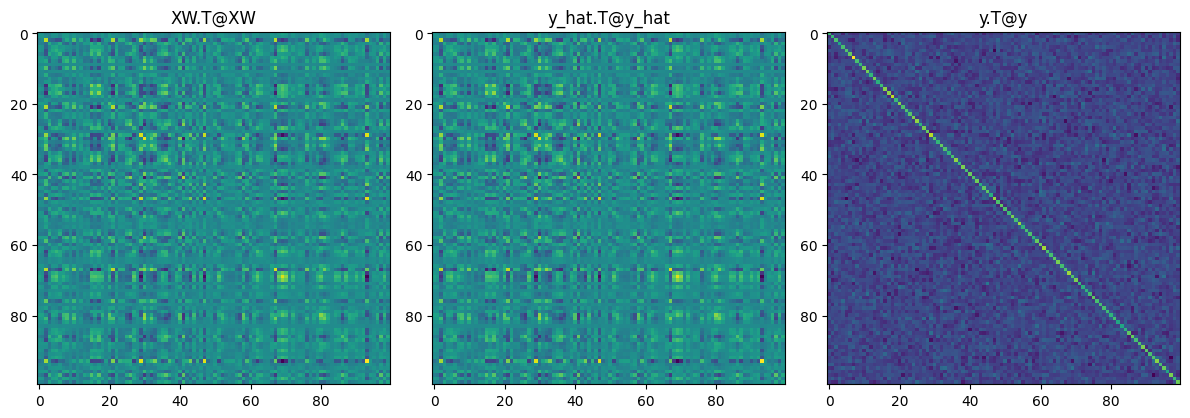

In [ ]:
data_dict = data_dict_l[1]
print(f'S = {data_dict["C"].length_corridors[0]}, A = {data_dict["C"].max_move}')
X = data_dict['X']
y = data_dict['y']
loc_y = data_dict['loc_y']
action_taken = data_dict['action_taken']
N = X.shape[0]

XT_X = X.T @ X /N
XT_y = X.T @ y /N
W = torch.linalg.pinv(XT_X) @ XT_y  

XW = (X@W).cpu().numpy()
y = y.cpu().numpy()



X = X.cpu().numpy()
y = y
Ux, Sx, Vx = np.linalg.svd(X, full_matrices=False)
Uy, Sy, Vy = np.linalg.svd(y, full_matrices=False)

y_hat = Ux@Ux.T@Uy@np.diag(Sy)@Vy

XT_X = X.T @ X
XT_y = X.T @ y
W = np.linalg.pinv(XT_X) @ XT_y  

fig, axs = plt.subplots(1, 3, figsize=(12, 5))
axs[0].imshow(XW.T@XW)
axs[0].set_title("XW.T@XW")
axs[1].imshow(y_hat.T@y_hat)
axs[1].set_title("y_hat.T@y_hat")
axs[2].imshow(y.T@y)
axs[2].set_title("y.T@y")
plt.tight_layout()
plt.show()

/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/avivra/Desktop/project/RepresentationShaping/venv/lib/python3.12/site-packages/matplotlib/collections.py:200: ComplexWarning: Casting complex values to real discards the imaginary part
  offsets = np.asanyarray(offsets, float)


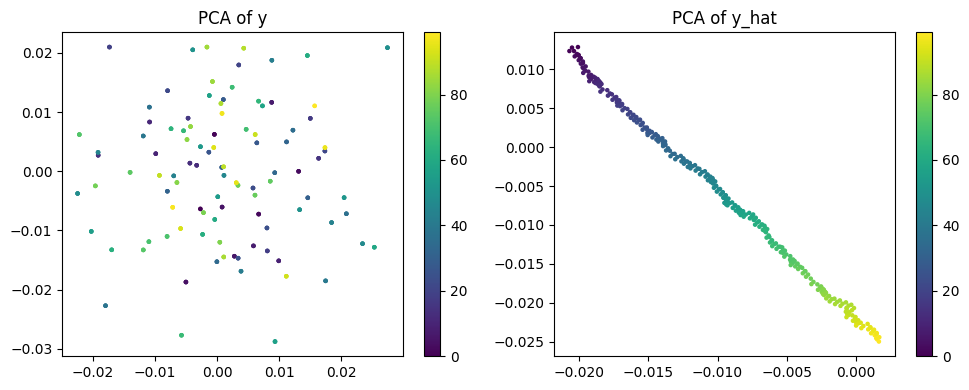

In [ ]:

y_y = y@y.T
y_hat_y_hat = Ux@Ux.T@Uy@np.diag(Sy**2)@Uy.T@Ux@Ux.T



fig, axs = plt.subplots(1, 2, figsize=(10, 4))
cond = abs(action_taken) <= 1
sc0 = axs[0].scatter(y_pca[cond, 0], y_pca[cond, 1], c=loc_y[cond], cmap='viridis', s=5)
axs[0].set_title('PCA of y')
plt.colorbar(sc0, ax=axs[0])

sc1 = axs[1].scatter(y_hat_pca[cond, 0], y_hat_pca[cond, 1], c=loc_y[cond], cmap='viridis', s=5)
axs[1].set_title('PCA of y_hat')
plt.colorbar(sc1, ax=axs[1])

plt.tight_layout()
plt.show()


In [ ]:
C.print_progress = False
N = C.length_corridors[0]
n = int(np.sqrt(N))
fig, axs = plt.subplots(n, n, figsize=(n*3, n*3))
for max_move, ax in zip(range(1,N), axs.flatten()):
    C.max_move = max_move
    data_dict = run_sim_wrapper(C)
    data_dict_l.append(data_dict)
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()

    XT_X = X.T @ X
    XT_y = X.T @ y
    S = np.linalg.pinv(XT_X) @ XT_y  
    ax.imshow(S)

In [ ]:
C.print_progress = False
N = C.length_corridors[0]
n = int(np.sqrt(N))
fig, axs = plt.subplots(n, n, figsize=(n*3, n*3))
for max_move, ax in zip(range(1,N), axs.flatten()):
    C.max_move = max_move
    data_dict = run_sim_wrapper(C)
    data_dict_l.append(data_dict)
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()

    XT_X = X.T @ X
    XT_y = X.T @ y
    S = np.linalg.pinv(XT_X) @ XT_y  
    U, S, Vt = np.linalg.svd(S)
    ax.plot(U[:,:2])

In [ ]:
C.print_progress = False
N = C.length_corridors[0]
fig, ax = plt.subplots(1, 1, figsize=(20, 5))
for max_move in tqdm(range(1,N)):
    C.max_move = max_move
    data_dict = run_sim_wrapper(C)
    data_dict_l.append(data_dict)
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()

    XT_X = X.T @ X
    XT_y = X.T @ y
    S = np.linalg.pinv(XT_X) @ XT_y  
    U, S, Vt = np.linalg.svd(S)
    plt.plot(np.arange(1, S.shape[0]+1), S, lw=0.5, marker='o', markersize=1)
plt.xscale('log')

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

def get_r2(y):
    x = np.arange(y.shape[0]).reshape(-1, 1)
    # Prepare the data for linear regression
    lr = LinearRegression()
    lr.fit(x, y)
    y_pred = lr.predict(x)
    r2 = r2_score(y, y_pred)
    return r2

In [ ]:
C.print_progress = False
N = C.length_corridors[0]
PR_l = []
eigv_score_l = []
for max_move in tqdm(range(1,N)):
    C.max_move = max_move
    data_dict = run_sim_wrapper(C)
    data_dict_l.append(data_dict)
    X = data_dict['X'].cpu().numpy()
    y = data_dict['y'].cpu().numpy()

    XT_X = X.T @ X
    XT_y = X.T @ y
    S = np.linalg.pinv(XT_X) @ XT_y  
    U, S, Vt = np.linalg.svd(S)
    eigv_score_l.append(1-max(get_r2(U[:-1,0]), get_r2(U[:-1,1])))
    PR_l.append(np.sum(S)**2/np.sum(S**2))


In [ ]:
plt.scatter(PR_l, eigv_score_l, c=np.arange(1,N))
plt.scatter(PR_l[N//2], eigv_score_l[N//2], c='red', s=100)
plt.colorbar()
plt.yscale('log')
plt.xscale('log')
plt.xlabel('PR')
plt.ylabel('Eigv Score')

In [ ]:
plt.plot(PR_l)